In [53]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

In [54]:
def cost_function(X, y, w, b):
    m = X.shape[0]
    pred = X @ w + b
    cost = np.sum((pred - y)**2) / (2*m)
    return cost

In [55]:
def gradient(X, y, w, b):
    m = X.shape[0]
    pred = X @ w + b
    error = pred - y

    dj_dw = (X.T @ error)/m
    dj_db = np.sum(error)/m
    return dj_dw, dj_db

In [66]:
def gradient_descent(X, y, w, b, ite , cost_function , gradient , alpha):
    J_history = []

    for i in range(ite):
        dj_dw, dj_db = gradient(X,y,w,b)

        w -= alpha*dj_dw
        b -= alpha*dj_db

        if(i<10000):
            J_history.append(cost_function(X,y,w,b))

        if i % (ite/10) == 0:
            print(f"Iteration {i:4d}: Cost {float(J_history[-1]):8.2f}")

    return w, b, J_history

Iteration    0: Cost   438.90
Iteration 1000: Cost   438.90
Iteration 2000: Cost   438.90
Iteration 3000: Cost   438.90
Iteration 4000: Cost   438.90
Iteration 5000: Cost   438.90
Iteration 6000: Cost   438.90
Iteration 7000: Cost   438.90
Iteration 8000: Cost   438.90
Iteration 9000: Cost   438.90


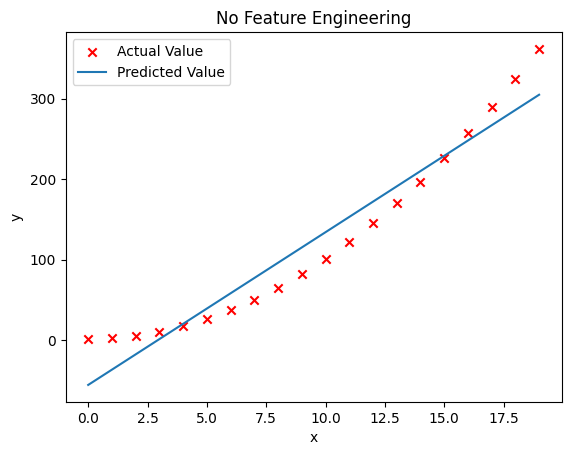

In [73]:
x = np.arange(0,20,1)
y = 1 + x**2
X = x.reshape(-1,1)

w_init , b_init , J_hist = gradient_descent(X,y,np.array([19],dtype=float),-56.0,10000,cost_function,gradient,1e-7)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("No Feature Engineering")
plt.plot(x,X@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()

Iteration    0: Cost 1359067655.37
Iteration 1000: Cost 13954438.83
Iteration 2000: Cost 145428.57
Iteration 3000: Cost  3664.47
Iteration 4000: Cost  2209.11
Iteration 5000: Cost  2194.17
Iteration 6000: Cost  2194.01
Iteration 7000: Cost  2194.01
Iteration 8000: Cost  2194.01
Iteration 9000: Cost  2194.01


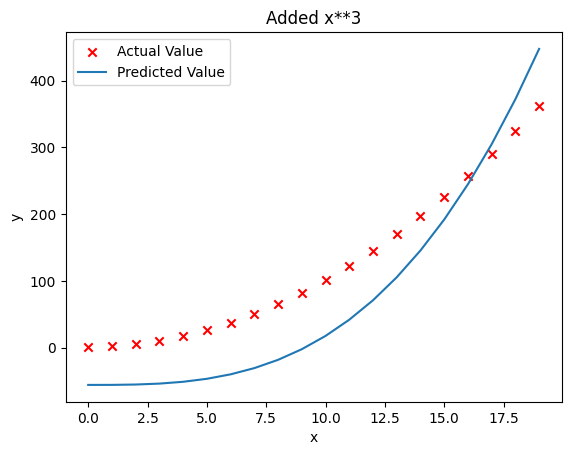

In [88]:
x = np.arange(0,20,1)
y = 1 + x**2
X = x**3
X = X.reshape(-1,1)

w_init , b_init , J_hist = gradient_descent(X,y,np.array([19],dtype=float),-56.0,10000,cost_function,gradient,3e-10)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Added x**3")
plt.plot(x,X@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()

Iteration    0: Cost 216905.86
Iteration 1000: Cost   783.41
Iteration 2000: Cost   729.49
Iteration 3000: Cost   683.46
Iteration 4000: Cost   644.15
Iteration 5000: Cost   610.58
Iteration 6000: Cost   581.92
Iteration 7000: Cost   557.44
Iteration 8000: Cost   536.53
Iteration 9000: Cost   518.67


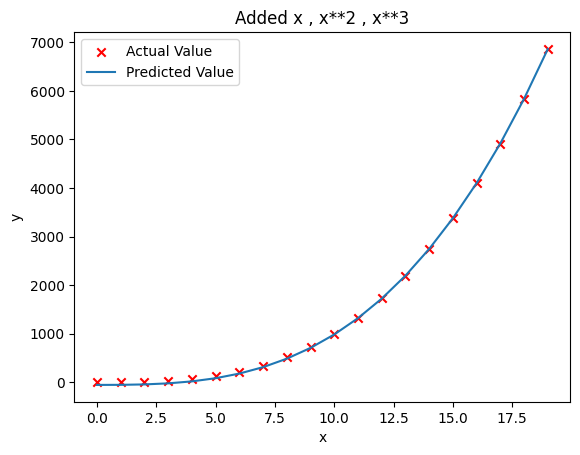

In [104]:
x = np.arange(0,20,1)
y = x**3
X = np.c_[x,x**2,x**3]

w_init , b_init , J_hist = gradient_descent(X,y,np.zeros(3),-56.0,10000,cost_function,gradient,1e-7)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Added x , x**2 , x**3")
plt.plot(x,X@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()

In [105]:
def zscore_normalization(X):
    mu = np.mean(X,axis=0)
    sigma = np.std(X,axis=0)
    x_norm = (X-mu)/sigma

    return x_norm

Iteration    0: Cost 22550.64
Iteration 1000: Cost 22543.68
Iteration 2000: Cost 22536.72
Iteration 3000: Cost 22529.77
Iteration 4000: Cost 22522.82
Iteration 5000: Cost 22515.87
Iteration 6000: Cost 22508.92
Iteration 7000: Cost 22501.98
Iteration 8000: Cost 22495.04
Iteration 9000: Cost 22488.10


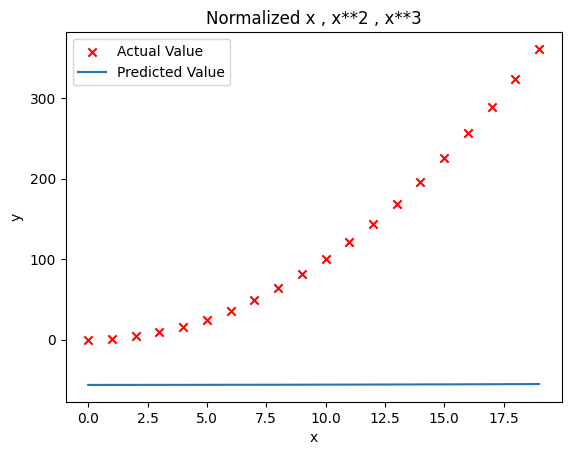

In [114]:
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]

X_norm = zscore_normalization(X)

w_init , b_init , J_hist = gradient_descent(X_norm,y,np.zeros(3),-56.0,10000,cost_function,gradient,1e-7)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Normalized x , x**2 , x**3")
plt.plot(x,X_norm@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()

Iteration    0: Cost 16293.51
Iteration 1000: Cost     4.22
Iteration 2000: Cost     3.24
Iteration 3000: Cost     2.49
Iteration 4000: Cost     1.91
Iteration 5000: Cost     1.46
Iteration 6000: Cost     1.12
Iteration 7000: Cost     0.86
Iteration 8000: Cost     0.66
Iteration 9000: Cost     0.51


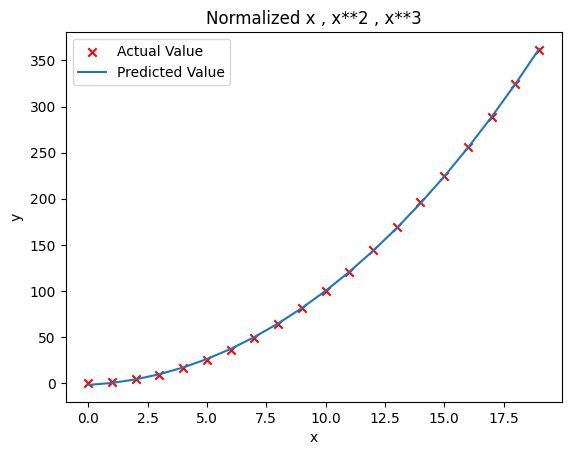

In [115]:
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]

X_norm = zscore_normalization(X)

w_init , b_init , J_hist = gradient_descent(X_norm,y,np.zeros(3),-56.0,10000,cost_function,gradient,1e-1)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Normalized x , x**2 , x**3")
plt.plot(x,X_norm@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()

Text(0, 0.5, 'y')

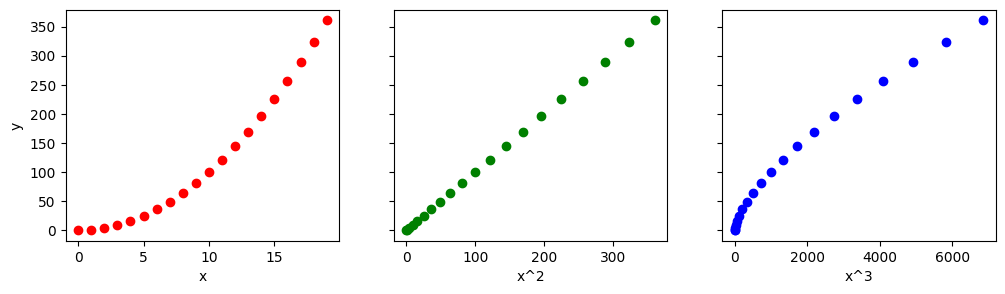

In [121]:
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]
x_feature = ['x','x^2','x^3']
color = ['r','g','b']

fig,ax = plt.subplots(1,3,figsize=(12,3),sharey=True)

for i in range(len(ax)):
    ax[i].scatter(X[:,i],y,c=color[i])
    ax[i].set_xlabel(x_feature[i])
ax[0].set_ylabel("y")

Iteration    0: Cost  1270.50
Iteration 1000: Cost     0.20
Iteration 2000: Cost     0.20
Iteration 3000: Cost     0.20
Iteration 4000: Cost     0.19
Iteration 5000: Cost     0.19
Iteration 6000: Cost     0.19
Iteration 7000: Cost     0.19
Iteration 8000: Cost     0.19
Iteration 9000: Cost     0.19


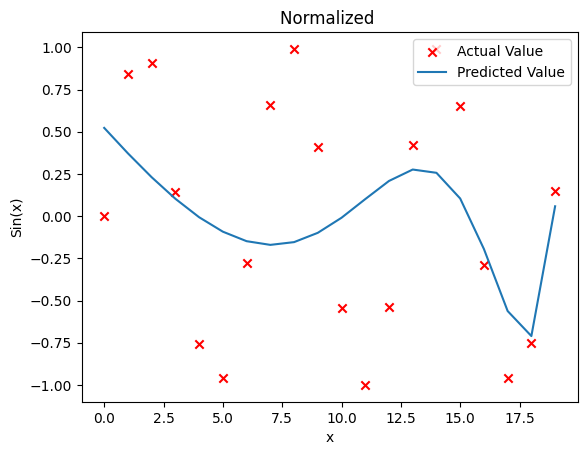

In [130]:
x = np.arange(0,20,1)
y = np.sin(x)
X = np.c_[x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10,x**11,x**12,x**13]

X_norm = zscore_normalization(X)

w_init , b_init , J_hist = gradient_descent(X_norm,y,np.zeros(13),-56.0,10000,cost_function,gradient,1e-1)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Normalized ")
plt.plot(x,X_norm@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("Sin(x)");plt.legend();plt.show()

Iteration    0: Cost  1270.33
Iteration 1000: Cost     0.02
Iteration 2000: Cost     0.01
Iteration 3000: Cost     0.01
Iteration 4000: Cost     0.01
Iteration 5000: Cost     0.01
Iteration 6000: Cost     0.00
Iteration 7000: Cost     0.00
Iteration 8000: Cost     0.00
Iteration 9000: Cost     0.00


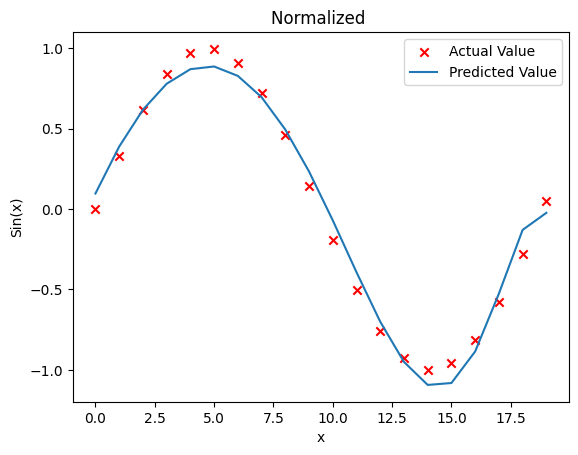

In [133]:
x = np.arange(0,20,1)
y = np.sin(x/3)
X = np.c_[x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10,x**11,x**12,x**13]

X_norm = zscore_normalization(X)

w_init , b_init , J_hist = gradient_descent(X_norm,y,np.zeros(13),-56.0,10000,cost_function,gradient,1e-1)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Normalized ")
plt.plot(x,X_norm@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("Sin(x)");plt.legend();plt.show()

Iteration    0: Cost  1272.86
Iteration 1000: Cost     0.00
Iteration 2000: Cost     0.00
Iteration 3000: Cost     0.00
Iteration 4000: Cost     0.00
Iteration 5000: Cost     0.00
Iteration 6000: Cost     0.00
Iteration 7000: Cost     0.00
Iteration 8000: Cost     0.00
Iteration 9000: Cost     0.00


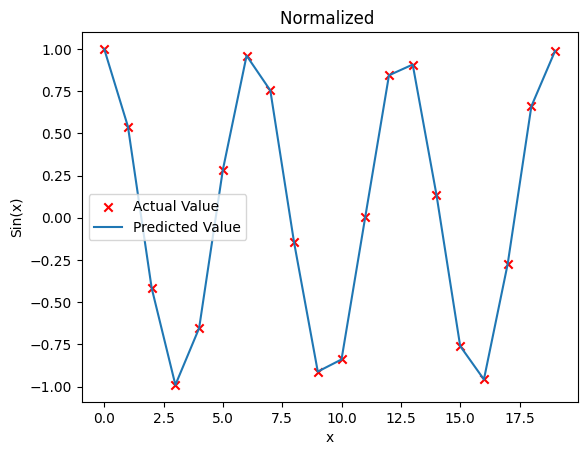

In [155]:
x = np.arange(0,20,1)
y = np.cos(x)
X = np.c_[np.sin(x),np.cos(x)]

X_norm = zscore_normalization(X)

w_init , b_init , J_hist = gradient_descent(X_norm,y,np.zeros(2),-56.0,10000,cost_function,gradient,1e-1)

plt.scatter(x,y,marker='x',c='r',label="Actual Value");plt.title("Normalized ")
plt.plot(x,X_norm@w_init+b_init,label="Predicted Value");plt.xlabel("x");plt.ylabel("Sin(x)");plt.legend();plt.show()